# RQ2 — Energy Efficient Deep Learning

      Model      RMSE   R2Score  RuntimeSeconds  EnergyProxy  EstimatedCO2
0    TinyNN  0.086937  0.999972       12.314463   123.144634      0.123145
1  MediumNN  0.063374  0.999985       14.800461   296.009221      0.296009
2   LargeNN  0.108527  0.999956       20.407828   612.234843      0.612235


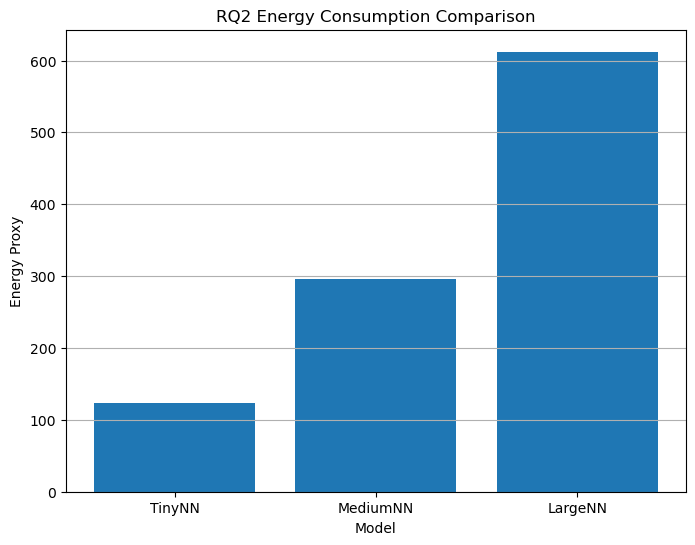

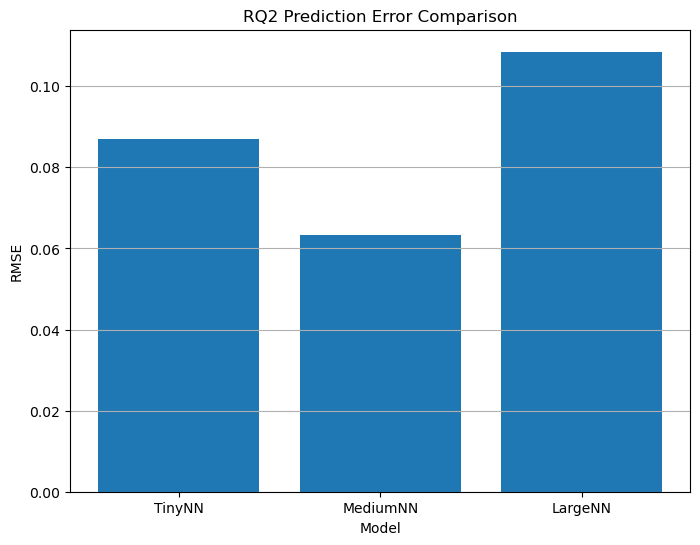

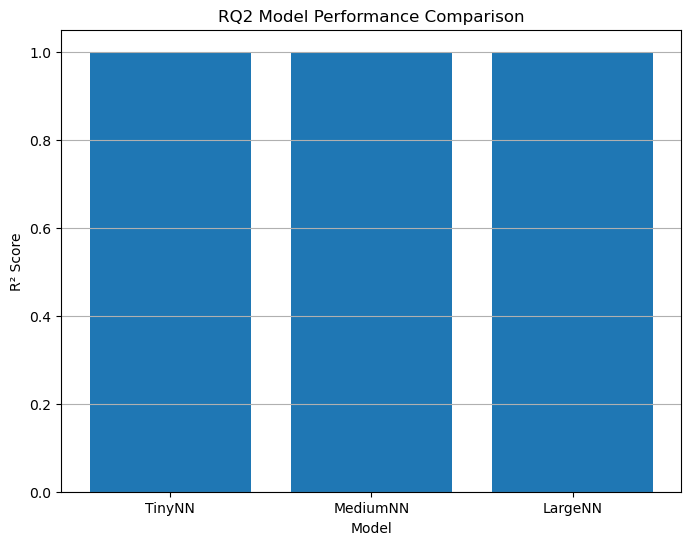

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.neural_network import MLPRegressor

# ====================================
# Load Dataset
# ====================================

df = pd.read_csv("iiot_smart_grid_dataset.csv")

# Remove Timestamp column if present
if "Timestamp" in df.columns:
    df = df.drop("Timestamp", axis=1)

# Remove missing values
df = df.dropna()

# Encode categorical columns
for col in df.select_dtypes(include='object').columns:
    df[col] = LabelEncoder().fit_transform(df[col])

# ====================================
# Features and Target
# ====================================

X = df.drop("Energy_Efficiency_Score", axis=1)
y = df["Energy_Efficiency_Score"]

# ====================================
# Feature Scaling
# ====================================

scaler = StandardScaler()
X = scaler.fit_transform(X)

# ====================================
# Train Test Split
# ====================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# ====================================
# Neural Network Architectures
# ====================================

models = {
    "TinyNN": MLPRegressor(
        hidden_layer_sizes=(16,),
        max_iter=500,
        random_state=42
    ),

    "MediumNN": MLPRegressor(
        hidden_layer_sizes=(32,16),
        max_iter=500,
        random_state=42
    ),

    "LargeNN": MLPRegressor(
        hidden_layer_sizes=(64,32,16),
        max_iter=500,
        random_state=42
    )
}

results = []

# ====================================
# Train Models
# ====================================

for name, model in models.items():

    start = time.time()

    model.fit(X_train, y_train)

    runtime = time.time() - start

    preds = model.predict(X_test)

    rmse = np.sqrt(
        mean_squared_error(
            y_test,
            preds
        )
    )

    r2 = r2_score(
        y_test,
        preds
    )

    # Energy proxy
    layers_count = len(model.hidden_layer_sizes)

    energy_proxy = runtime * layers_count * 10

    estimated_co2 = energy_proxy * 0.001

    results.append([
        name,
        rmse,
        r2,
        runtime,
        energy_proxy,
        estimated_co2
    ])

# ====================================
# Results Table
# ====================================

results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "RMSE",
        "R2Score",
        "RuntimeSeconds",
        "EnergyProxy",
        "EstimatedCO2"
    ]
)

print(results_df)

results_df.to_csv(
    "RQ2_results_table.csv",
    index=False
)

# ====================================
# Figure 1
# Energy Consumption Comparison
# ====================================

plt.figure(figsize=(8,6))

plt.bar(
    results_df["Model"],
    results_df["EnergyProxy"]
)

plt.xlabel("Model")
plt.ylabel("Energy Proxy")
plt.title("RQ2 Energy Consumption Comparison")

plt.grid(axis="y")

plt.savefig(
    "RQ2_energy_comparison.pdf",
    bbox_inches="tight"
)

plt.show()

# ====================================
# Figure 2
# RMSE Comparison
# ====================================

plt.figure(figsize=(8,6))

plt.bar(
    results_df["Model"],
    results_df["RMSE"]
)

plt.xlabel("Model")
plt.ylabel("RMSE")
plt.title("RQ2 Prediction Error Comparison")

plt.grid(axis="y")

plt.savefig(
    "RQ2_rmse_comparison.pdf",
    bbox_inches="tight"
)

plt.show()

# ====================================
# Figure 3
# R² Score Comparison
# ====================================

plt.figure(figsize=(8,6))

plt.bar(
    results_df["Model"],
    results_df["R2Score"]
)

plt.xlabel("Model")
plt.ylabel("R² Score")
plt.title("RQ2 Model Performance Comparison")

plt.grid(axis="y")

plt.savefig(
    "RQ2_r2_comparison.pdf",
    bbox_inches="tight"
)

plt.show()